# PCA and variance stablization

In [12]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from EDX import *
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import copy
from importlib import reload

from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime
from sklearn.decomposition import PCA
import matplotlib.patches as patches

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load aligned tile and crop it

In [2]:
with open('results/preprocessed_edx/20251201_142554_tile_aligned_20frames.pkl', 'rb') as file:
    tile = pickle.load(file)

tile.apply("crop", parameters = {"crop_idx": (slice(50,tile.EDX_dim[0]-50),slice(50,tile.EDX_dim[1]-50),slice(None,None,None))})
tile.apply("binning", parameters={"dim": (974,974,250)})
tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})
h, w, b = tile.EDX_dim

In [15]:
# MinMaxing the HSI
tile.EDX = MinMax(tile.EDX)

### PCA before stablization

In [3]:
# Regular
pca = PCA()
pca.fit(tile.EDX_2D)

# Scaled (i.e. variance stablized)
pca_scaled = PCA()
G = np.mean(tile.EDX,axis=2).reshape(h*w,1)
G = np.ones_like(G)   # optional
H = np.mean(np.mean(tile.EDX,axis=0),axis=0).reshape(b,-1)
W = G@np.transpose(H)
W = np.sqrt(W)    
hsi_2D_weighted = np.divide(tile.EDX_2D,W)
pca_scaled.fit(hsi_2D_weighted)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


### Scree-plot

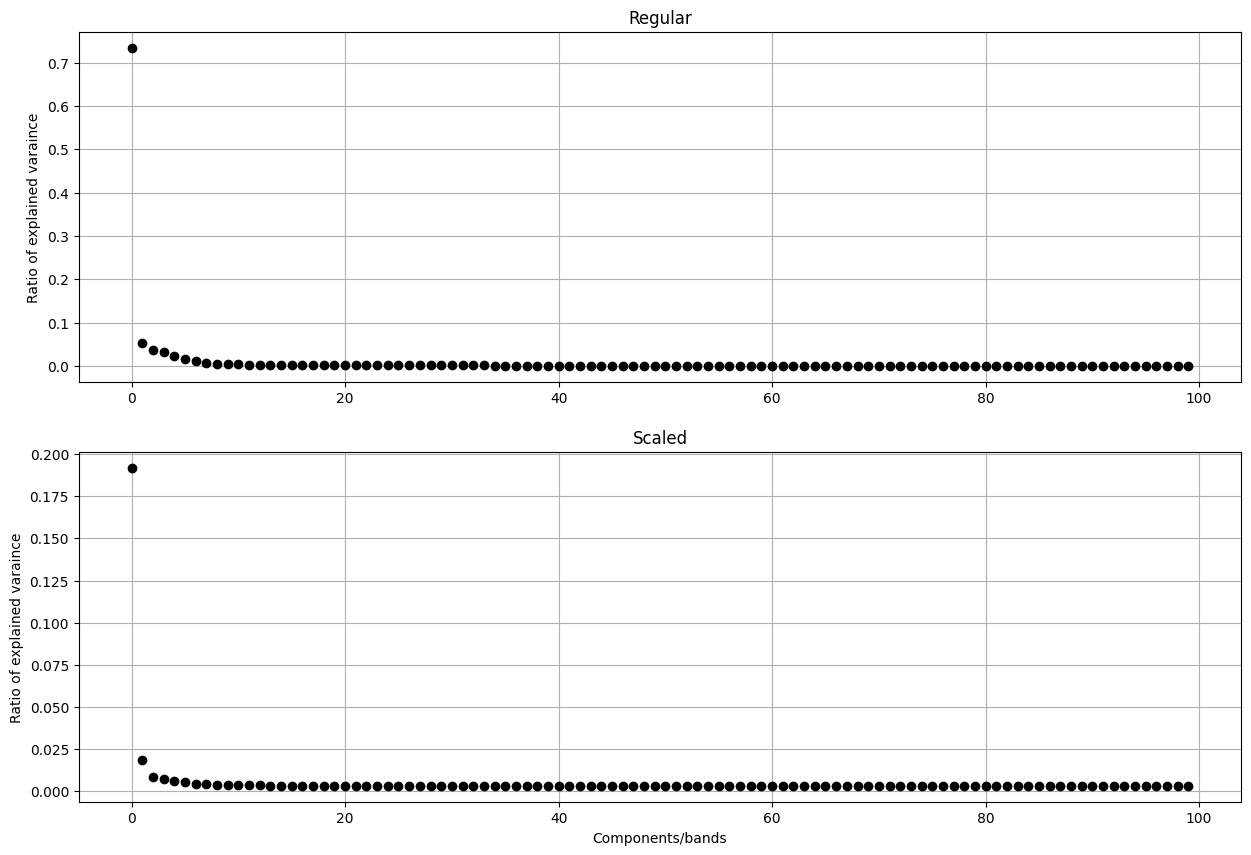

In [4]:
f, ax = plt.subplots(2,1,figsize=(15,10))
tmp = 100
ax[0].plot(range(tmp),pca.explained_variance_ratio_[:tmp],'ok')
ax[0].set_title('Regular')
#ax[0].set_xlabel('Components/bands')
ax[0].set_ylabel('Ratio of explained varaince')
ax[0].grid('ON')

ax[1].plot(range(tmp),pca_scaled.explained_variance_ratio_[:tmp],'ok')
ax[1].set_title('Scaled')
ax[1].set_xlabel('Components/bands')
ax[1].set_ylabel('Ratio of explained varaince')
ax[1].grid('ON')

### Principal component scores

In [5]:
pca_scores = pca.transform(tile.EDX_2D)
pca_scores_scaled = pca_scaled.transform(hsi_2D_weighted)    
pca_scores = pca_scores.reshape((974,974,250))
pca_scores_scaled = pca_scores_scaled.reshape((974,974,250))

In [ ]:
tmp = 25
f, ax = plt.subplots(tmp,2,figsize=(8,tmp*5))

for i in range(tmp):
    ax[i][0].imshow(pca_scores[:,:,i],cmap='gray')
    ax[i][0].set_title('PCA %02d normal' % i)
    ax[i][1].imshow(pca_scores_scaled[:,:,i],cmap='gray')
    ax[i][1].set_title('PCA %02d scaled' % i)
    ax[i][0].axis('OFF')
    ax[i][1].axis('OFF')

### Reconstruction with the same number of components

In [7]:
n_components = 4
n_components_scaled = 4

# Regular
pca = PCA(n_components_scaled)
pca.fit(tile.EDX_2D)
pca_scores = pca.transform(tile.EDX_2D)
EDX_recon = pca.inverse_transform(pca_scores)

# Scaled (i.e. variance stablized)
pca_scaled = PCA(n_components_scaled)
G = np.mean(tile.EDX,axis=2).reshape(h*w,1)
H = np.mean(np.mean(tile.EDX,axis=0),axis=0).reshape(b,-1)
W = G@np.transpose(H)
W = np.sqrt(W)    
hsi_2D_weighted = np.divide(tile.EDX_2D,W)
pca_scaled.fit(hsi_2D_weighted)
pca_scores_scaled = pca_scaled.transform(hsi_2D_weighted)   


pca_scores_scaled_reshaped = pca_scores_scaled.reshape((974,974,n_components_scaled))
pca_scores_scaled = pca_scores_scaled_reshaped.reshape((974**2,n_components_scaled))

EDX_recon_scaled = pca_scaled.inverse_transform(pca_scores_scaled)
EDX_recon_scaled = np.multiply(EDX_recon_scaled,W) 

### Set to tile objects

In [8]:
tile_recon = tile.apply('crop',parameters={'crop_idx': (slice(None,None,None),slice(None,None,None),slice(None,None,None))},copy_instance='True')
tile_recon_scaled = tile.apply('crop',parameters={'crop_idx': (slice(None,None,None),slice(None,None,None),slice(None,None,None))},copy_instance='True')
tile_recon.EDX = EDX_recon.reshape(tile.EDX_dim)
tile_recon_scaled.EDX = EDX_recon_scaled.reshape(tile.EDX_dim)

### Compare visually

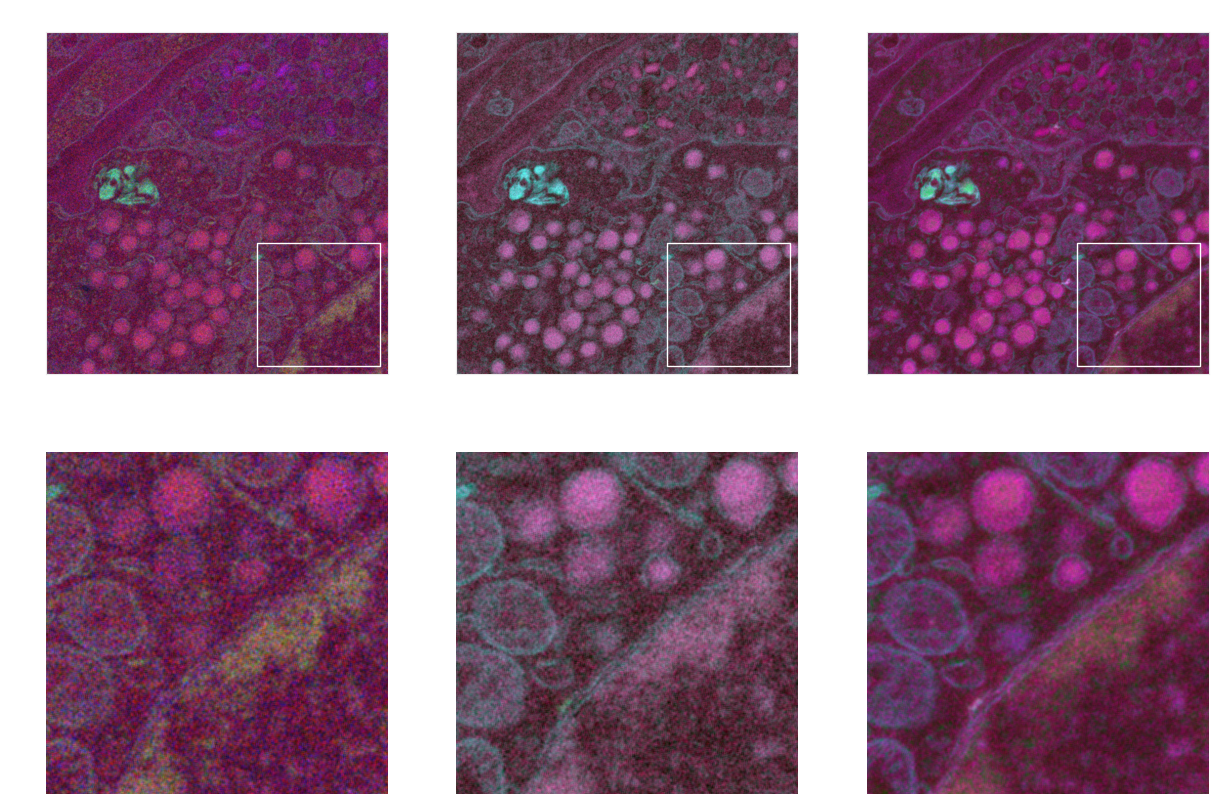

In [14]:
corr = 0

#bands = [25-corr,25-corr,25-corr]
#bands = [28-corr,28-corr,28-corr]
#bands = [4-corr,4-corr,4-corr]
#bands = [24-corr,24-corr,24-corr]
#bands = [9-corr,9-corr,9-corr]


bands = [4-corr,25-corr,28-corr]


#zoom = (slice(400,600),slice(150,350),slice(None))
zoom = (slice(600,950),slice(600,950),slice(None))
#zoom = (slice(500,700),slice(650,850),slice(None))
#zoom = (slice(None,None),slice(None,None),slice(None))
#zoom = (slice(1250,1750),slice(1250,1750),slice(None))
#zoom = (slice(250,450),slice(150,350),slice(None))

f, ax = plt.subplots(2,3,figsize=(15,10))
ax[0][0].imshow(tile.FalseColor(bands))
ax[0][0].set_title('Raw')
ax[0][1].imshow(tile_recon.FalseColor(bands))
ax[0][1].set_title('PCA reconstructed')
ax[0][2].imshow(tile_recon_scaled.FalseColor(bands))
ax[0][2].set_title('PCA reconstructed')

ax[1][0].imshow(tile.FalseColor(bands)[zoom])
ax[1][1].imshow(tile_recon.FalseColor(bands)[zoom])
ax[1][2].imshow(tile_recon_scaled.FalseColor(bands)[zoom])


# Extract rectangle from zoom slices
ys, xs, _ = zoom
y0 = ys.start or 0
y1 = ys.stop or metric_noisy.shape[0]
x0 = xs.start or 0
x1 = xs.stop or metric_noisy.shape[1]



ax[0][0].add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))
ax[0][1].add_patch(
    patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))

ax[0][2].add_patch(
    patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                      linewidth=1, edgecolor='white', facecolor='none'))


ax[1][0].axis('off')
ax[1][1].axis('off')
ax[1][2].axis('off')


make_dark_presentation(f,text_color='white', line_width=2.5, transparent=True)
plt.savefig("/Users/aj/Desktop/WIPfigures/PCA_denoising.png", dpi=300, transparent=True)